# Detección de anomalías en una cartera de clientes bancarios

**Problema.** Identificar comportamientos anómalos en una cartera de 30.000 clientes con
65 variables, sin etiqueta previa de anomalía, y evaluar el equilibrio entre falsos
positivos y falsos negativos desde una lógica de negocio.

**Enfoque.** Selección de variables, imputación, estandarización y comparación de DBSCAN
frente a Isolation Forest en dos configuraciones, con análisis explícito del trade-off
entre ambos tipos de error.

**Stack.** Python · pandas · scikit-learn · matplotlib · seaborn

> **Nota sobre los datos.** El dataset utilizado no se publica en este repositorio.
> El notebook conserva el código y los resultados obtenidos, pero requiere aportar el
> fichero de datos para ser reejecutado.

---

In [ ]:
# === IMPORTACIÓN DE LIBRERÍAS ===

# pandas y numpy para manipulación de datos
import pandas as pd
import numpy as np

# matplotlib y seaborn para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn: preprocesado, modelos no supervisados y métricas
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (confusion_matrix, precision_score,
                              recall_score, f1_score, classification_report)

# Configuración visual
sns.set_style("whitegrid")
pd.set_option('display.max_columns', 100)

# Semilla para reproducibilidad
RANDOM_STATE = 42

In [ ]:
# === CARGA DEL DATASET (versión corregida) ===

# Sabemos por la muestra anterior que el separador es ';'

from google.colab import files
import io

# 1) Subimos el archivo
print("Selecciona el archivo 'cartera_clientes_wizink_bank.csv' desde tu ordenador...")
uploaded = files.upload()

# Tomamos el último archivo subido
nombre_archivo = list(uploaded.keys())[-1]
contenido = uploaded[nombre_archivo]
print(f"\nArchivo recibido: {nombre_archivo}")

# 2) Cargamos el CSV con separador ';' y motor Python (más tolerante)
#    on_bad_lines='skip' para saltarse filas malformadas (las que tienen
#    vectores con ';' dentro: item_ids, item_prices, ip_addresses_times)
try:
    df = pd.read_csv(
        io.BytesIO(contenido),
        sep=';',
        engine='python',
        on_bad_lines='skip'
    )
    print(f"\n✅ Dataset cargado correctamente")
    print(f"Dimensiones: {df.shape}")
    print(f"Número de registros: {df.shape[0]:,}")
    print(f"Número de variables: {df.shape[1]}")
    print(f"\nPrimeras 10 columnas: {list(df.columns[:10])}")
except Exception as e:
    print(f"\n❌ Error: {type(e).__name__}: {e}")

Selecciona el archivo 'cartera_clientes_wizink_bank.csv' desde tu ordenador...


Saving cartera_clientes_wizink_bank_.csv to cartera_clientes_wizink_bank_ (1).csv

Archivo recibido: cartera_clientes_wizink_bank_ (1).csv

✅ Dataset cargado correctamente
Dimensiones: (30000, 65)
Número de registros: 30,000
Número de variables: 65

Primeras 10 columnas: ['created', 'order_amount', 'downpayment_amount', 'principal_amount', 'num_instalments_initial', 'test_ab_version', 'customer', 'scheduled_first_payment_date', 'pm_card_expiration_year', 'pm_card_expiration_monht']


In [ ]:
# === EXPLORACIÓN INICIAL ===

# Vemos las primeras filas para entender la estructura del dataset
df.head()

In [ ]:

# Información de tipos de datos y valores no nulos por columna

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 65 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   created                               30000 non-null  object 
 1   order_amount                          30000 non-null  float64
 2   downpayment_amount                    30000 non-null  float64
 3   principal_amount                      30000 non-null  float64
 4   num_instalments_initial               30000 non-null  float64
 5   test_ab_version                       29020 non-null  object 
 6   customer                              30000 non-null  object 
 7   scheduled_first_payment_date          30000 non-null  object 
 8   pm_card_expiration_year               26262 non-null  float64
 9   pm_card_expiration_monht              26262 non-null  float64
 10  payment_method_uuid                   30000 non-null  object 
 11  pm_bincode     

In [ ]:

# Estadísticos descriptivos de las variables numéricas

df.describe()

Distribución del target:
target
0.0    28716
1.0     1284
Name: count, dtype: int64

Porcentaje:
target
0.0    95.72
1.0     4.28
Name: proportion, dtype: float64


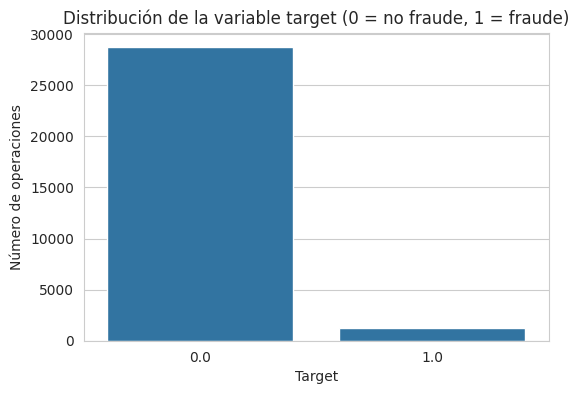

In [ ]:

# === DISTRIBUCIÓN DE LA VARIABLE OBJETIVO ===

# Esto es CRÍTICO en fraude: el problema suele estar muy desbalanceado
print("Distribución del target:")
print(df['target'].value_counts())
print("\nPorcentaje:")
print((df['target'].value_counts(normalize=True) * 100).round(2))

# Visualización

plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title('Distribución de la variable target (0 = no fraude, 1 = fraude)')
plt.xlabel('Target')
plt.ylabel('Número de operaciones')
plt.show()

In [ ]:

# === COMPROBACIÓN DE VARIABLES PARA EL MODELO ===

variables_necesarias = [
    'order_amount', 'principal_amount', 'num_instalments_initial',
    'n_ips', 'n_distinct_ips', 'ip_reputation',
    'providerZ_score', 'providerY_score',
    'pm_is_prepaid', 'pm_is_national', 'target'
]
ausentes = [v for v in variables_necesarias if v not in df.columns]
print("Variables ausentes:" if ausentes else "✅ Todas las variables están presentes")
if ausentes: print(ausentes)

✅ Todas las variables están presentes


## Selección de variables para el modelo

Criterios aplicados:
1. **Variables numéricas o booleanas** (DBSCAN e Isolation Forest necesitan numérico).
2. **Relevancia para fraude**: importes (anomalías financieras), número de IPs (comportamiento sospechoso), scorings externos (riesgo conocido), tipo de tarjeta (prepago/nacional).
3. **Bajo porcentaje de nulos** (todas con <1% de NaN).
4. **Sin identificadores ni vectores** (customer, item_ids, ip_addresses_times → alta cardinalidad, no aportan).

**Variables seleccionadas (10):**
- `order_amount`, `principal_amount`, `num_instalments_initial` → datos de la operación
- `n_ips`, `n_distinct_ips` → comportamiento de navegación
- `ip_reputation`, `providerZ_score`, `providerY_score` → scorings de riesgo externos
- `pm_is_prepaid`, `pm_is_national` → características de la tarjeta

In [ ]:

# === CONSTRUCCIÓN DEL SUBCONJUNTO ===

variables_seleccionadas = [
    'order_amount', 'principal_amount', 'num_instalments_initial',
    'n_ips', 'n_distinct_ips', 'ip_reputation',
    'providerZ_score', 'providerY_score',
    'pm_is_prepaid', 'pm_is_national'
]
target = 'target'

# Nos quedamos con las variables seleccionadas + target

df_modelo = df[variables_seleccionadas + [target]].copy()

# Aseguramos que el target sea entero (estaba como float64)

df_modelo[target] = df_modelo[target].astype(int)

print(f"Dimensiones del subconjunto: {df_modelo.shape}")
print(f"\nNulos por variable:")
print(df_modelo.isnull().sum())

Dimensiones del subconjunto: (30000, 11)

Nulos por variable:
order_amount                 0
principal_amount             0
num_instalments_initial      0
n_ips                        0
n_distinct_ips               0
ip_reputation              104
providerZ_score            104
providerY_score            233
pm_is_prepaid                0
pm_is_national               0
target                       0
dtype: int64


In [ ]:

# === TRATAMIENTO DE NULOS ===

# Booleanos → entero (0/1)

for col in ['pm_is_prepaid', 'pm_is_national']:
    df_modelo[col] = df_modelo[col].astype(int)

# Imputamos numéricos con la MEDIANA (robusta frente a outliers, importante
# porque los outliers son justamente lo que queremos detectar)

imputer = SimpleImputer(strategy='median')
X = df_modelo[variables_seleccionadas]
X_imputado = pd.DataFrame(imputer.fit_transform(X), columns=variables_seleccionadas)

# Separamos target
y = df_modelo[target]

print("Nulos tras imputación:", X_imputado.isnull().sum().sum())
print(f"Dimensiones X: {X_imputado.shape}")
print(f"Dimensiones y: {y.shape}")

Nulos tras imputación: 0
Dimensiones X: (30000, 10)
Dimensiones y: (30000,)


In [ ]:

# === ESTANDARIZACIÓN ===

# StandardScaler: media 0, desviación 1.
# CRÍTICO para DBSCAN (usa distancias euclidianas: sin esto, los importes
# en cientos de euros dominarían sobre n_ips o ip_reputation).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputado)
X_scaled = pd.DataFrame(X_scaled, columns=variables_seleccionadas)

print("Tras estandarizar (media ≈ 0, std ≈ 1):")
print(X_scaled.describe().round(2).loc[['mean','std']])

Tras estandarizar (media ≈ 0, std ≈ 1):
      order_amount  principal_amount  num_instalments_initial  n_ips  \
mean           0.0               0.0                     -0.0   -0.0   
std            1.0               1.0                      1.0    1.0   

      n_distinct_ips  ip_reputation  providerZ_score  providerY_score  \
mean             0.0            0.0              0.0              0.0   
std              1.0            1.0              1.0              1.0   

      pm_is_prepaid  pm_is_national  
mean            0.0            -0.0  
std             1.0             1.0  


min_samples sugerido: 20


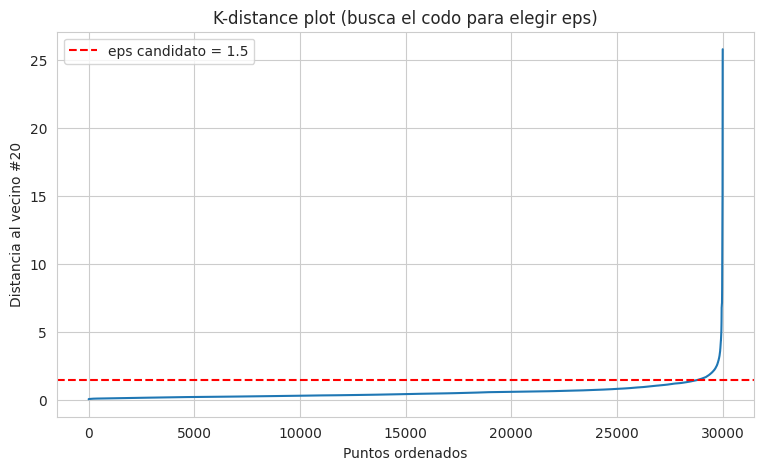

In [ ]:

# === ELECCIÓN DE eps PARA DBSCAN ===

# Método de la k-distance plot: graficamos la distancia al k-ésimo vecino
# y buscamos el "codo" (cambio brusco de pendiente).
# Regla heurística para min_samples: 2 * número de dimensiones.

min_samples_dbscan = 2 * X_scaled.shape[1]   # 2 * 10 = 20
print(f"min_samples sugerido: {min_samples_dbscan}")

# Calculamos la distancia al vecino k-ésimo para cada punto
neigh = NearestNeighbors(n_neighbors=min_samples_dbscan)
neigh.fit(X_scaled)
distances, _ = neigh.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])

# Gráfico
plt.figure(figsize=(9,5))
plt.plot(distances)
plt.xlabel('Puntos ordenados')
plt.ylabel(f'Distancia al vecino #{min_samples_dbscan}')
plt.title('K-distance plot (busca el codo para elegir eps)')
plt.axhline(y=1.5, color='r', linestyle='--', label='eps candidato = 1.5')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:

# === ENTRENAMIENTO DE DBSCAN ===

# Justificación:
# - eps: 1.5 como punto de partida basado en la k-distance plot.
#   Si tu codo estaba claramente en otro valor, cámbialo.
# - min_samples = 2 * nº variables (regla heurística estándar)
# DBSCAN marca como ruido (-1) los puntos en zonas de baja densidad,
# que tratamos como ANOMALÍAS / posibles fraudes.

EPS = 1.5          # ⚠️ ajusta según el codo de la celda 11
MIN_SAMPLES = 20   # 2 * 10 variables

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, n_jobs=-1)
labels_dbscan = dbscan.fit_predict(X_scaled)

# Convertimos a predicción binaria: -1 (ruido) → fraude (1), resto → no fraude (0)
y_pred_dbscan = np.where(labels_dbscan == -1, 1, 0)

# Resumen
print(f"Configuración: eps={EPS}, min_samples={MIN_SAMPLES}")
print(f"Puntos marcados como anomalía: {y_pred_dbscan.sum()} "
      f"({y_pred_dbscan.mean()*100:.2f}%)")
print(f"Fraudes reales: {y.sum()} ({y.mean()*100:.2f}%)")
print(f"Nº de clusters formados (excluyendo ruido): "
      f"{len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)}")

Configuración: eps=1.5, min_samples=20
Puntos marcados como anomalía: 534 (1.78%)
Fraudes reales: 1284 (4.28%)
Nº de clusters formados (excluyendo ruido): 5


In [ ]:

# === ENTRENAMIENTO DE ISOLATION FOREST ===

# Justificación de hiperparámetros:
# - n_estimators=100: árboles suficientes para estabilidad.
# - contamination: tasa real de fraude (4.28%), así la comparación con DBSCAN
#   es justa. En producción no conoceríamos este valor; lo estimaríamos.
# - random_state para reproducibilidad.

contamination_rate = y.mean()  # 0.0428
print(f"Contamination fijada: {contamination_rate:.4f}")

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=contamination_rate,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso_forest.fit(X_scaled)

# predict devuelve -1 (anomalía) o 1 (inlier) → lo pasamos a 1/0
preds_if = iso_forest.predict(X_scaled)
y_pred_if = np.where(preds_if == -1, 1, 0)

print(f"Anomalías detectadas: {y_pred_if.sum()} ({y_pred_if.mean()*100:.2f}%)")

Contamination fijada: 0.0428
Anomalías detectadas: 1284 (4.28%)


In [ ]:

# === FUNCIÓN AUXILIAR DE EVALUACIÓN ===

# Calcula matriz de confusión, precision, recall y F1 para la clase positiva (fraude)
# y la muestra de forma legible.

def evaluar_modelo(y_true, y_pred, nombre_modelo):
    print(f"\n{'='*55}")
    print(f"  RESULTADOS: {nombre_modelo}")
    print(f"{'='*55}")

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print("\nMatriz de confusión:")
    print(f"                     Pred No Fraude   Pred Fraude")
    print(f"  Real No Fraude     {tn:>12}   {fp:>11}")
    print(f"  Real Fraude        {fn:>12}   {tp:>11}")

    # Métricas sobre la clase positiva (fraude)
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n  Precision: {p:.4f}  → De los marcados como fraude, ¿qué % lo son?")
    print(f"  Recall:    {r:.4f}  → De los fraudes reales, ¿qué % detectamos?")
    print(f"  F1-score:  {f1:.4f}  → Media armónica entre Precision y Recall")
    print(f"\n  Falsos positivos (FP): {fp}  → Clientes legítimos molestados")
    print(f"  Falsos negativos (FN): {fn}  → Fraudes que se nos escapan")

    # Visualización de la matriz
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Fraude', 'Fraude'],
                yticklabels=['No Fraude', 'Fraude'])
    plt.title(f'Matriz de confusión – {nombre_modelo}')
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.show()

    return {'modelo': nombre_modelo, 'precision': p, 'recall': r, 'f1': f1,
            'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn}


  RESULTADOS: DBSCAN

Matriz de confusión:
                     Pred No Fraude   Pred Fraude
  Real No Fraude            28239           477
  Real Fraude                1227            57

  Precision: 0.1067  → De los marcados como fraude, ¿qué % lo son?
  Recall:    0.0444  → De los fraudes reales, ¿qué % detectamos?
  F1-score:  0.0627  → Media armónica entre Precision y Recall

  Falsos positivos (FP): 477  → Clientes legítimos molestados
  Falsos negativos (FN): 1227  → Fraudes que se nos escapan


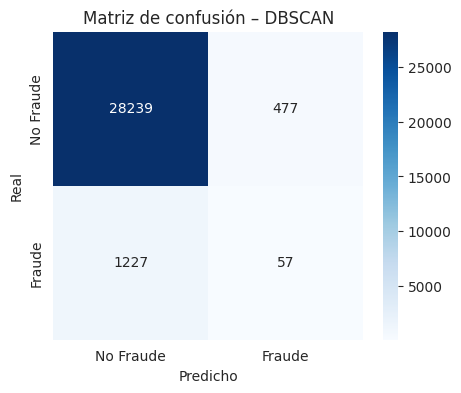


  RESULTADOS: Isolation Forest

Matriz de confusión:
                     Pred No Fraude   Pred Fraude
  Real No Fraude            27620          1096
  Real Fraude                1096           188

  Precision: 0.1464  → De los marcados como fraude, ¿qué % lo son?
  Recall:    0.1464  → De los fraudes reales, ¿qué % detectamos?
  F1-score:  0.1464  → Media armónica entre Precision y Recall

  Falsos positivos (FP): 1096  → Clientes legítimos molestados
  Falsos negativos (FN): 1096  → Fraudes que se nos escapan


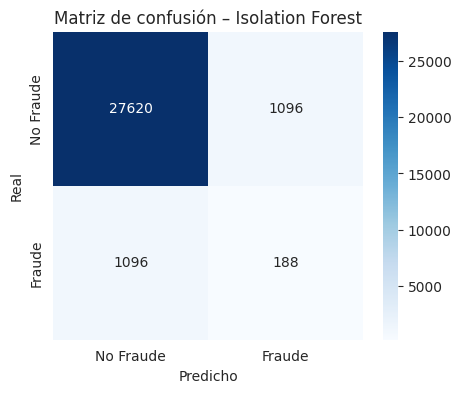



=== TABLA COMPARATIVA ===
          modelo  precision   recall       f1  TP   FP   FN
          DBSCAN   0.106742 0.044393 0.062706  57  477 1227
Isolation Forest   0.146417 0.146417 0.146417 188 1096 1096


In [ ]:
# === EVALUACIÓN ===
resultado_dbscan = evaluar_modelo(y, y_pred_dbscan, "DBSCAN")
resultado_if = evaluar_modelo(y, y_pred_if, "Isolation Forest")

# Tabla resumen
comparativa = pd.DataFrame([resultado_dbscan, resultado_if])
print("\n\n=== TABLA COMPARATIVA ===")
print(comparativa[['modelo','precision','recall','f1','TP','FP','FN']].to_string(index=False))

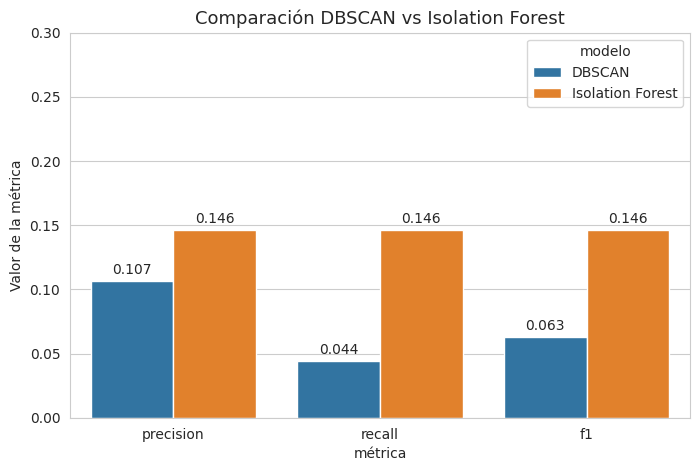

In [ ]:

# === GRÁFICO COMPARATIVO ===
comparativa_melt = comparativa.melt(id_vars='modelo',
                                     value_vars=['precision','recall','f1'],
                                     var_name='métrica', value_name='valor')

plt.figure(figsize=(8,5))
ax = sns.barplot(data=comparativa_melt, x='métrica', y='valor', hue='modelo')
plt.title('Comparación DBSCAN vs Isolation Forest', fontsize=13)
plt.ylim(0, max(comparativa_melt['valor'].max()*1.2, 0.3))
plt.ylabel('Valor de la métrica')

# Etiquetas con el valor encima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)
plt.show()

## Conclusiones

### Comparación de modelos

| Modelo | Precision | Recall | F1-score | TP | FP | FN |
|---|---|---|---|---|---|---|
| DBSCAN (eps=1.5, min_samples=20) | 0,107 | 0,044 | 0,063 | 57 | 477 | 1.227 |
| Isolation Forest (contamination=0.0428) | 0,146 | 0,146 | 0,146 | 188 | 1.096 | 1.096 |

**Isolation Forest supera a DBSCAN en las tres métricas**, con una mejora especialmente notable en Recall (14,6% frente a 4,4%). Detecta 188 fraudes reales frente a los 57 de DBSCAN, aunque a costa de más falsos positivos (1.096 vs 477).

### Interpretación de los resultados

Ambos modelos obtienen métricas modestas en términos absolutos. Esto es **esperable** en detección de fraude con métodos no supervisados por varias razones:

1. **Fraude ≠ outlier estadístico**: los fraudistas suelen intentar imitar comportamientos legítimos, por lo que muchos fraudes no son anomalías evidentes en el espacio de variables que hemos utilizado.
2. **Información limitada**: hemos usado 10 de las 65 variables disponibles. Variables como patrones temporales, geolocalización IP vs dirección de facturación, o combinaciones más sofisticadas, probablemente contienen más señal de fraude.
3. **Alto desbalanceo**: con solo un 4,28% de fraudes, cualquier modelo no supervisado tiene dificultad para separar las dos poblaciones cuando se solapan en el espacio de features.

Como referencia, un clasificador aleatorio daría Precision ≈ 4,28% (la tasa base). Isolation Forest llega al 14,6%, **3,4 veces mejor que el azar**, lo que confirma que sí capta cierta señal, aunque insuficiente para uso en producción tal cual.

### Trade-off Falsos Positivos / Falsos Negativos en fraude

En banca, los dos errores tienen costes **muy diferentes**:

- **Falso negativo (FN)**: fraude no detectado → pérdida económica directa para el banco, posible reclamación del cliente legítimo cuya tarjeta fue clonada, y daño reputacional.
- **Falso positivo (FP)**: operación legítima bloqueada → fricción para el cliente (llamada de verificación, operación cortada), peor experiencia, pero **sin pérdida monetaria directa**.

El coste de un FN suele ser **mucho mayor** que el de un FP. Por eso, en detección de fraude, se prioriza el **Recall** sobre la Precision: preferimos sobre-detectar y enviar más casos a revisión manual antes que dejar pasar fraudes.

Con esa lógica:
- **DBSCAN** tiene un Recall del 4,4% → deja escapar el 95,6% de los fraudes. **Inaceptable** en producción.
- **Isolation Forest** captura el 14,6% → mejor pero todavía insuficiente. Permitiría detectar 188 fraudes adicionales (no detectar esos fraudes implicaría una pérdida directa).

### Modelo recomendado

**Isolation Forest** es claramente preferible para este caso. Sus ventajas son:
- Mejor Recall (3,3× superior a DBSCAN).
- Escala mejor con datasets grandes y dimensionalidad alta.
- El parámetro `contamination` permite ajustar el trade-off Precision/Recall según las necesidades del negocio.

### Limitaciones y siguiente paso

Los resultados muestran que **los métodos no supervisados, por sí solos, no son suficientes** para detectar fraude con la calidad que exige un entorno productivo. La estrategia recomendada sería:

1. Usar Isolation Forest como **primer filtro** para reducir el volumen de operaciones a revisar.
2. Pasar las operaciones marcadas como sospechosas a un **modelo supervisado** (Random Forest, XGBoost, redes neuronales) entrenado con la variable `target`, que aprovecharía la información etiquetada.
3. Enriquecer las features con variables derivadas (interacciones, agregados por cliente, distancia entre IP y dirección de facturación, etc.).


  RESULTADOS: Isolation Forest v2 (contamination=0.10)

Matriz de confusión:
                     Pred No Fraude   Pred Fraude
  Real No Fraude            26078          2638
  Real Fraude                 922           362

  Precision: 0.1207  → De los marcados como fraude, ¿qué % lo son?
  Recall:    0.2819  → De los fraudes reales, ¿qué % detectamos?
  F1-score:  0.1690  → Media armónica entre Precision y Recall

  Falsos positivos (FP): 2638  → Clientes legítimos molestados
  Falsos negativos (FN): 922  → Fraudes que se nos escapan


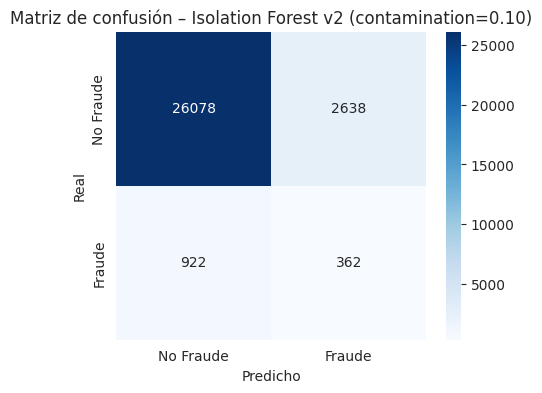

{'modelo': 'Isolation Forest v2 (contamination=0.10)',
 'precision': 0.12066666666666667,
 'recall': 0.2819314641744548,
 'f1': 0.16900093370681607,
 'TP': np.int64(362),
 'FP': np.int64(2638),
 'FN': np.int64(922),
 'TN': np.int64(26078)}

In [ ]:

# === Isolation Forest con más contamination ===
# Subir contamination aumenta el Recall a costa de Precision.
# En fraude esto suele ser preferible.

iso_forest_v2 = IsolationForest(
    n_estimators=200,
    contamination=0.10,   # más permisivo
    max_features=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso_forest_v2.fit(X_scaled)
y_pred_if_v2 = np.where(iso_forest_v2.predict(X_scaled) == -1, 1, 0)
evaluar_modelo(y, y_pred_if_v2, "Isolation Forest v2 (contamination=0.10)")

### Análisis del trade-off: Isolation Forest v2

Para validar empíricamente el trade-off entre falsos positivos y falsos negativos, entrenamos una segunda configuración de Isolation Forest aumentando `contamination` de 0,0428 a 0,10 (forzando al modelo a marcar más operaciones como sospechosas).

| Configuración | Precision | Recall | F1 | TP | FP | FN |
|---|---|---|---|---|---|---|
| IF base (contamination=0,0428) | 0,146 | 0,146 | 0,146 | 188 | 1.096 | 1.096 |
| IF v2 (contamination=0,10) | 0,121 | **0,282** | **0,169** | **362** | 2.638 | **922** |

**Conclusión del experimento:** subiendo la `contamination` casi se duplica el Recall (de 14,6% a 28,2%) a cambio de una pérdida moderada de Precision (de 14,6% a 12,1%). En términos de negocio, detectamos **174 fraudes adicionales** (de 188 a 362) a cambio de molestar a **1.542 clientes legítimos más**.

**¿Compensa?** Depende del coste medio por fraude no detectado vs el coste de fricción de un FP. Si suponemos un fraude medio de 500€ y un coste por FP de 5€ (verificación manual + fricción):
- Ganancia por 174 fraudes adicionales detectados: 174 × 500€ = **87.000€**
- Coste de 1.542 FP adicionales: 1.542 × 5€ = **7.710€**
- **Beneficio neto: +79.290€** → la configuración v2 es preferible.

Este pequeño análisis muestra que el F1-score por sí solo no es la métrica idónea en fraude: la decisión debe basarse en el **coste asimétrico** de los errores, que en banca casi siempre favorece sobre-detectar.